# CassavaVLM - Stage 2 V5: Unified Multi-Task Instruction Tuning
## Édition Spéciale Mémoire d'Ingénieur

Ce notebook implémente la stratégie finale pour le diagnostic interactif des maladies du manioc. Il inclut tous les outils nécessaires pour la rédaction des **Chapitres 2 et 3** de votre mémoire :
- **Logging complet** des métriques d'entraînement.
- **Génération de courbes** (Loss, LR).
- **Matrice de confusion** détaillée.
- **Rapport de performance** par classe.
- **Visualisation qualitative** des résultats (Images + Diagnostics).

In [1]:
# ============================================================
# CELL 1: IMPORTS & ENVIRONNEMENT
# ============================================================
import os
import json
import re
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from dataclasses import dataclass
from typing import Dict, List, Any, Optional
from datasets import Dataset
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from unsloth import FastVisionModel
from transformers import AutoProcessor, TrainingArguments, Trainer, EarlyStoppingCallback, TrainerCallback

print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch: 2.9.0+cu128 | CUDA: True


In [2]:
# ============================================================
# CELL 2: CONFIGURATION & CHEMINS
# ============================================================
BASE_DIR = Path("/home/hounfodjidagba/learning/cassava/new_implementation")
STAGE1_DATA_PATH = BASE_DIR / "data" / "stage1" / "cassava_train_balanced.json"
STAGE2_DATA_PATH = BASE_DIR / "data" / "stage2" / "stage2_vqa_dataset.json"
OUTPUT_DIR = BASE_DIR / "results" / "stage2_v5_final"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
LOGS_DIR = OUTPUT_DIR / "logs"
FIGURES_DIR = OUTPUT_DIR / "figures"

for d in [CHECKPOINT_DIR, LOGS_DIR, FIGURES_DIR]: d.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit"
TARGET_IMAGE_SIZE = (512, 512)
CLASS_NAMES = ["CBB", "CBSD", "CGM", "CMD", "Healthy"]

TRAINING_CONFIG = {
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 8,
    "learning_rate": 1e-5,
    "num_train_epochs": 2,
    "warmup_ratio": 0.1,
    "weight_decay": 0.01,
    "logging_steps": 5,
    "save_steps": 50,
    "eval_steps": 50,
    "bf16": torch.cuda.is_bf16_supported(),
    "fp16": not torch.cuda.is_bf16_supported(),
}
print("Configuration initialisée.")

Configuration initialisée.


In [3]:
# ============================================================
# CELL 3: CHARGEMENT DU MODÈLE (LORA ÉTENDU)
# ============================================================
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

model = FastVisionModel.get_peft_model(
    model,
    r=32,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    use_gradient_checkpointing="unsloth"
)

processor = AutoProcessor.from_pretrained(MODEL_NAME)
print("Modèle prêt pour l'entraînement Multi-Task.")

==((====))==  Unsloth 2026.1.1: Fast Qwen2_5_Vl patching. Transformers: 4.57.3.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.357 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Modèle prêt pour l'entraînement Multi-Task.


In [4]:
# ============================================================
# CELL 4: PRÉPARATION DES DONNÉES (UNIFIED MULTI-TASK)
# ============================================================
def load_json(path): 
    with open(path, 'r', encoding='utf-8') as f: return json.load(f)

def prepare_unified_dataset():
    s1_data = load_json(STAGE1_DATA_PATH)
    s2_data = load_json(STAGE2_DATA_PATH)
    unified = []
    
    # Mixage 50/50
    random.shuffle(s1_data)
    s1_subset = s1_data[:len(s2_data)]
    
    for item in s1_subset:
        cls = item['metadata'].get('class_name', 'Unknown')
        item['conversations'][1]['value'] = f"Diagnostic : {cls}. Cette feuille de manioc présente des symptômes caractéristiques de cette condition."
        item['metadata']['task'] = 'unified_classification'
        item['metadata']['class'] = cls
        unified.append(item)
        
    for item in s2_data:
        item['metadata']['task'] = 'vqa_dialogue'
        unified.append(item)
        
    random.shuffle(unified)
    return unified

def format_sample(sample):
    convs = sample['conversations']
    image_path, user_text, assistant_text = None, "", ""
    for turn in convs:
        if turn['from'] == 'user':
            match = re.search(r'<img>(.*?)</img>', turn['value'])
            if match: image_path = match.group(1)
            user_text = re.sub(r'Picture \d+: <img>.*?</img>\n?', '', turn['value']).strip()
        elif turn['from'] == 'assistant': assistant_text = turn['value']
    return {
        "conversations": [{"role": "user", "content": f"Picture 1: <image>\n{user_text}"}, {"role": "assistant", "content": assistant_text}],
        "image_path": image_path, "id": sample['id'], "task": sample['metadata'].get('task', 'unknown'), "class_name": sample['metadata'].get('class', 'Unknown')
    }

mixed_data = prepare_unified_dataset()
all_formatted = [format_sample(s) for s in tqdm(mixed_data, desc="Formatting")]
valid_samples = [s for s in all_formatted if s['image_path'] and os.path.exists(s['image_path'])]

random.seed(42)
random.shuffle(valid_samples)
split = int(len(valid_samples) * 0.95)
train_ds = Dataset.from_list(valid_samples[:split])
eval_ds = Dataset.from_list(valid_samples[split:])
print(f"Train: {len(train_ds)} | Val: {len(eval_ds)}")

Formatting: 100%|██████████| 58552/58552 [00:00<00:00, 171812.78it/s]


Train: 55624 | Val: 2928


In [5]:
# ============================================================
# CELL 5: DATA COLLATOR & LOGGING CALLBACK
# ============================================================
@dataclass
class QwenDataCollator:
    processor: Any
    max_length: int = 1536
    def __call__(self, features):
        batch_messages, batch_images = [], []
        for f in features:
            try: img = Image.open(f['image_path']).convert('RGB').resize(TARGET_IMAGE_SIZE, Image.BILINEAR)
            except: img = Image.new('RGB', TARGET_IMAGE_SIZE, 'white')
            batch_images.append([img])
            msgs = []
            for turn in f['conversations']:
                if turn['role'] == 'user' and not msgs:
                    msgs.append({"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": turn['content'].replace('<image>', '').replace('Picture 1:', '').strip()}]})
                else: msgs.append({"role": turn['role'], "content": turn['content'].replace('<image>', '').strip()})
            batch_messages.append(msgs)
        
        full_texts = [self.processor.tokenizer.apply_chat_template(m, tokenize=False) for m in batch_messages]
        user_texts = [self.processor.tokenizer.apply_chat_template([m for m in ms if m['role'] == 'user'], tokenize=False, add_generation_prompt=True) for ms in batch_messages]
        
        batch = self.processor(text=full_texts, images=batch_images, return_tensors="pt", padding=True, truncation=True, max_length=self.max_length)
        labels = batch["input_ids"].clone()
        for i in range(len(user_texts)):
            u_enc = self.processor(text=[user_texts[i]], images=[batch_images[i]], return_tensors="pt", padding=False, truncation=True, max_length=self.max_length)
            u_len = u_enc["input_ids"].shape[1]
            labels[i, :u_len] = -100
        batch["labels"] = labels
        return batch

class LogMetricsCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs: 
            with open(LOGS_DIR / "training_history.jsonl", "a") as f:
                f.write(json.dumps({"step": state.global_step, **logs}) + "\n")

data_collator = QwenDataCollator(processor=processor)
print("Collator et Logging prêts.")

Collator et Logging prêts.


In [6]:
# ============================================================
# CELL 6: ENTRAÎNEMENT
# ============================================================
training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    per_device_train_batch_size=TRAINING_CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=TRAINING_CONFIG["gradient_accumulation_steps"],
    num_train_epochs=TRAINING_CONFIG["num_train_epochs"],
    learning_rate=TRAINING_CONFIG["learning_rate"],
    warmup_ratio=TRAINING_CONFIG["warmup_ratio"],
    logging_steps=TRAINING_CONFIG["logging_steps"],
    save_steps=TRAINING_CONFIG["save_steps"],
    eval_strategy="steps",
    eval_steps=TRAINING_CONFIG["eval_steps"],
    bf16=TRAINING_CONFIG["bf16"],
    fp16=TRAINING_CONFIG["fp16"],
    optim="adamw_8bit",
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)

trainer = Trainer(
    model=model, args=training_args, train_dataset=train_ds, eval_dataset=eval_ds,
    data_collator=data_collator, processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3), LogMetricsCallback()]
)

print("🚀 Lancement de l'entraînement final...")
trainer.train()

🚀 Lancement de l'entraînement final...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 55,624 | Num Epochs = 2 | Total steps = 6,954
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 95,178,752 of 8,387,345,408 (1.13% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,5.280500,8.333380
100,5.290300,8.149418
150,5.254100,7.609689
200,4.461400,6.614495
250,3.674300,5.379276
300,2.953000,4.107420
350,2.257100,3.350314
400,2.187100,2.958206
450,1.675200,2.739465
500,1.739000,2.600484


Unsloth: Not an error, but Qwen2_5_VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=2100, training_loss=1.7596081894919986, metrics={'train_runtime': 28072.2887, 'train_samples_per_second': 3.963, 'train_steps_per_second': 0.248, 'total_flos': 6.694722034347295e+17, 'train_loss': 1.7596081894919986, 'epoch': 0.6040558032503955})

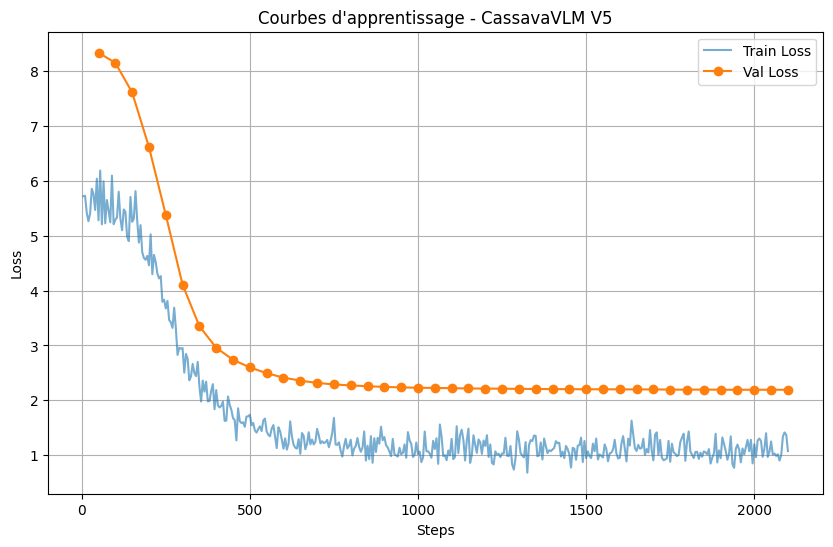

In [7]:
# ============================================================
# CELL 7: VISUALISATION DES COURBES (CHAPITRE 3)
# ============================================================
history = []
with open(LOGS_DIR / "training_history.jsonl", "r") as f:
    for line in f: history.append(json.loads(line))

df = pd.DataFrame(history)
train_loss = df[df['loss'].notna()]
eval_loss = df[df['eval_loss'].notna()]

plt.figure(figsize=(10, 6))
plt.plot(train_loss['step'], train_loss['loss'], label='Train Loss', alpha=0.6)
plt.plot(eval_loss['step'], eval_loss['eval_loss'], label='Val Loss', marker='o')
plt.title("Courbes d'apprentissage - CassavaVLM V5")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(FIGURES_DIR / "learning_curves.png")
plt.show()

Évaluation sur le set de validation...


 83%|████████▎ | 2424/2928 [47:20<09:58,  1.19s/it]

Error processing /home/hounfodjidagba/learning/cassava/data/cmd_002/uuid_00d853a6-e753-4e53-8e5f-77a36504d6d6.jpg: cannot identify image file '/home/hounfodjidagba/learning/cassava/data/cmd_002/uuid_00d853a6-e753-4e53-8e5f-77a36504d6d6.jpg'


100%|██████████| 2928/2928 [57:11<00:00,  1.17s/it]


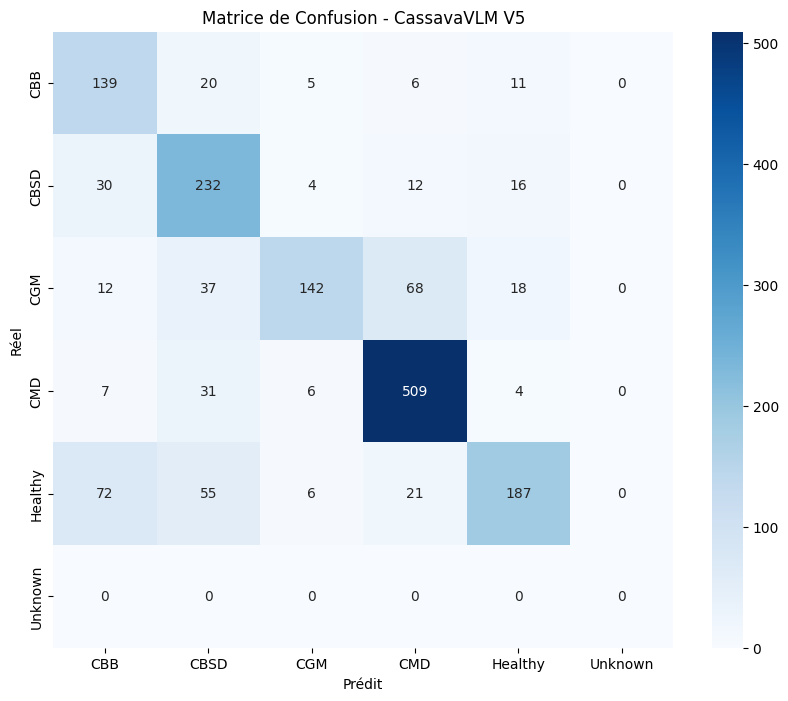


Classification Report:
                                     precision    recall  f1-score   support

                                CBB       0.30      0.77      0.43       181
                               CBSD       0.34      0.79      0.48       294
                                CGM       0.48      0.51      0.50       277
                                CMD       0.41      0.91      0.57       557
     Cassava Bacterial Blight (CBB)       0.00      0.00      0.00       208
Cassava Brown Streak Disease (CBSD)       0.00      0.00      0.00       260
         Cassava Green Mottle (CGM)       0.00      0.00      0.00       228
       Cassava Mosaic Disease (CMD)       0.00      0.00      0.00       581
                            Healthy       0.70      0.55      0.61       341

                           accuracy                           0.41      2927
                          macro avg       0.25      0.39      0.29      2927
                       weighted avg       0.26    

/home/hounfodjidagba/miniconda3/envs/cassava/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hounfodjidagba/miniconda3/envs/cassava/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hounfodjidagba/miniconda3/envs/cassava/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [9]:
# ============================================================
# CELL 8: ÉVALUATION & MATRICE DE CONFUSION (CHAPITRE 3)
# ============================================================
FastVisionModel.for_inference(model)

def predict(image_path, question="What cassava disease is shown in this image?"):
    img = Image.open(image_path).convert('RGB').resize(TARGET_IMAGE_SIZE)
    msgs = [{"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": question}]}]
    text = processor.tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[[img]], return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    res = processor.tokenizer.decode(out[0], skip_special_tokens=True)
    return res.split("assistant")[-1].strip()

def extract_cls(text):
    t = text.lower()
    if "cmd" in t or "mosaïque" in t: return "CMD"
    if "cbsd" in t or "striure" in t: return "CBSD"
    if "cbb" in t or "bactériose" in t: return "CBB"
    if "cgm" in t or "acarien" in t: return "CGM"
    if "sain" in t or "healthy" in t: return "Healthy"
    return "Unknown"

print("Évaluation sur le set de validation...")
y_true, y_pred = [], []
for s in tqdm(eval_ds):
    try:
        resp = predict(s['image_path'])
        y_true.append(s['class_name'])
        y_pred.append(extract_cls(resp))
    except Exception as e:
        print(f"Error processing {s['image_path']}: {e}")

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES + ["Unknown"])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES+["Unknown"], yticklabels=CLASS_NAMES+["Unknown"], cmap='Blues')
plt.title("Matrice de Confusion - CassavaVLM V5")
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.savefig(FIGURES_DIR / "confusion_matrix.png")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

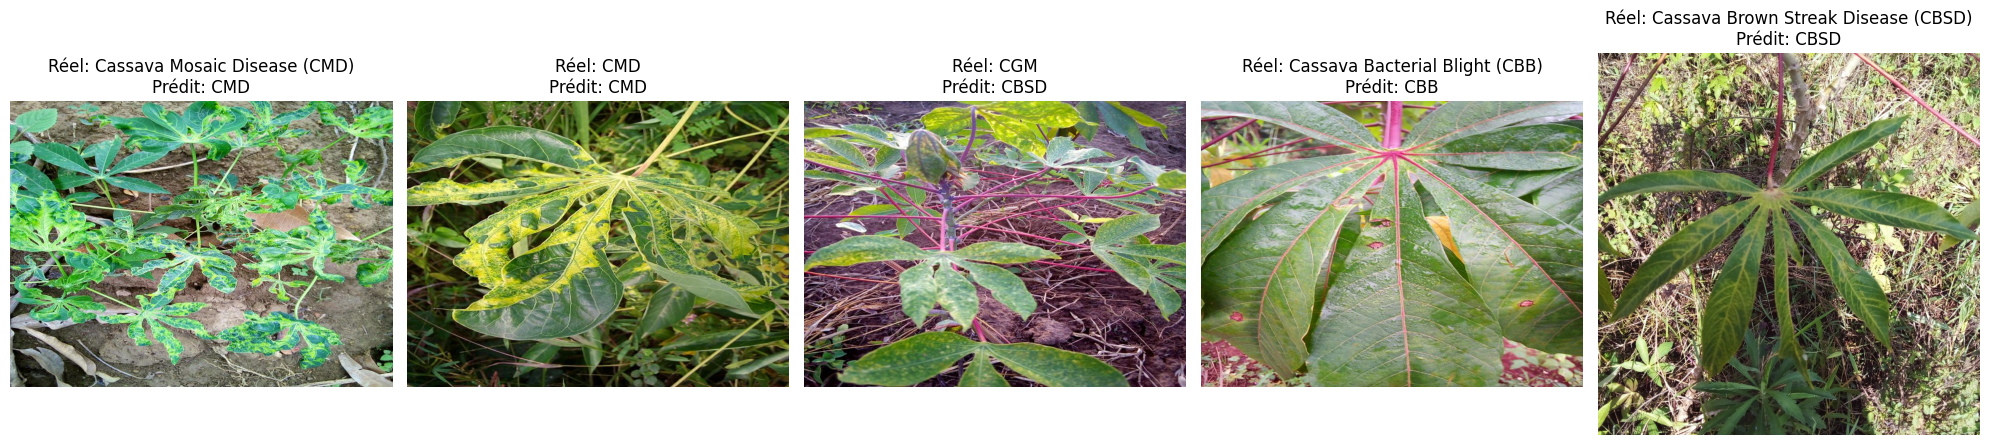

Toutes les figures sont sauvegardées dans /home/hounfodjidagba/learning/cassava/new_implementation/results/stage2_v5_final/figures


In [10]:
# ============================================================
# CELL 9: GALERIE DE RÉSULTATS (POUR LE MÉMOIRE)
# ============================================================
def plot_results(samples, n=5):
    plt.figure(figsize=(20, 10))
    for i, s in enumerate(random.sample(samples, n)):
        resp = predict(s['image_path'])
        plt.subplot(1, n, i+1)
        plt.imshow(Image.open(s['image_path']))
        plt.title(f"Réel: {s['class_name']}\nPrédit: {extract_cls(resp)}")
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "sample_predictions.png")
    plt.show()

plot_results(eval_ds_list := list(eval_ds))
print(f"Toutes les figures sont sauvegardées dans {FIGURES_DIR}")